# 12章 輻輳とウインドウ制御

本章では、前章に続いてTCPを扱います。
特に、TCPの通信レートを調整するウインドウ制御について学習します。
前章ではACKと再送による信頼性の実現について学びましたが、もしパケットを1つ送ってACKを待ち、それから次のパケットを送って・・、といった手順をとっていては時間がかかりすぎます。
そのため実際には、ある程度のパケット数をまとめて送ってしまいます。
ただし、あまりにも多くのパケットを送ってしまうと、ネットワークが混雑しパケットロスや遅延の増大を招いてしまい、逆効果です。
本章では、送信するパケット数を調節するための手法であるウインドウ制御について実装しながら学んでいきます。

## ウインドウ制御

### 輻輳とは

通信ネットワークは、多くのノード、多くのアプリケーションで共用されます。
あらゆるノードが大量のデータを送受信したとしたら、リンクが混雑して遅延が大きくなってしまいます。
これは道路が渋滞するのと同じ原理であり、このようなネットワークの混雑は輻輳と呼ばれます。
輻輳が発生すると、アプリケーションの品質に大きな影響が出ます。
動画がコマ落ちしたり、スムーズに通話できなくなったりします。

ネットワークの利用者は、それぞれ自由に通信しようとしますし、それを管理する管理者のようなものは存在しません。
よって、送信ノードが送信時点でネットワークの混み具合を判断して，送信するパケット量を調整する必要があるのです。

### 輻輳制御とは

TCP輻輳制御は、ネットワークの状態に応じて適切にデータの送信速度を調整する仕組みです。
大まかには、空いているときには高速にデータを送信し、混んでいるときには無理せずゆっくりとデータを送信します。
以下では、最も基本的かつ古典的な輻輳制御アルゴリズムであるTCP Tahoeを実装していきます。

Tahoeをはじめとする輻輳制御アルゴリズムは、輻輳ウィンドウ（cwnd）という仕組みを用います。
cwndとは、まとめて送信できるデータ量を指し、cwndが大きくなるほどACKを受け取る前に多くのパケットを送出します。
ここでは、Tahoeの大まかな動作を説明しておきます。

1. スロースタートフェーズ：通信開始時、cwndを1 MSS（最大セグメントサイズ）に設定します。ACKを受信するたびにcwndを1 MSSずつ増加させることで、cwndを指数関数的に増加させます。

2. 輻輳回避フェーズ：cwndがスロースタート閾値（ssthresh）に達すると、このフェーズに移行します。cwndを1RTTごとに1 MSSずつ増加させます。つまり、送信データ量をゆっくり増加させるようにします。

3. 輻輳検出：タイムアウトやトリプル重複ACKにより輻輳を検出します。輻輳検出時には、ssthreshを現在のcwndの半分に設定し、cwndを1 MSSにリセットし、スロースタートフェーズに戻ります。

4. 高速再送：トリプル重複ACKを受信した場合、再送タイムアウトを待たずにパケットを再送します。


### 既存クラスのインポート
前章と同様に、本書のコードをアップロードしてあるGitHubレポジトリから、必要なファイルをインポートするため、以下のコードブロックを実行してください。


In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

Cloning into 'network-simulator'...
remote: Enumerating objects: 1696, done.
remote: Counting objects: 100% (364/364), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 1696 (delta 263), reused 313 (delta 212), pack-reused 1332
Receiving objects: 100% (1696/1696), 312.38 KiB | 5.29 MiB/s, done.
Resolving deltas: 100% (1264/1264), done.


### `Node`クラスのアップデート

#### TCP接続情報の修正

新しいTCP接続の情報を初期化するためのメソッドである`initialize_connection_info` に、輻輳制御に関連する変数を追加します。

- cwnd (Congestion Window)

輻輳ウィンドウは、ネットワークの輻輳を防ぐために送信側が一度に送信できる最大データ量を制御するためのパラメタです。cwndの値はデータ転送中に変動し、輻輳が発生しそうな場合には減少し、輻輳が解消された場合には増加します。

- ssthresh (Slow Start Threshold)

スロースタート閾値は、スロースタートから輻輳回避に移行するための境界値です。cwndがssthreshの値に達すると、輻輳制御アルゴリズムはスロースタートから輻輳回避へと切り替わります。スロースタートではcwndが指数関数的に増加しますが、輻輳回避では線形的に増加します。

- congestion_state

輻輳制御の現在の状態を示します。初期化時には'slow_start' (スロースタート) に設定されます。cwndがssthreshに達した後、cwndを線形的に増加させるcongestion_avoidanceフェーズに移行する。

```
def initialize_connection_info(self, connection_key=None, state='CLOSED', sequence_number=0, acknowledgment_number=0, data=b''):
    # TCP接続情報を辞書として初期化します
    self.tcp_connections[connection_key] = {
        'state': state,  # 接続の初期状態
        'sequence_number': sequence_number,  # 初期シーケンス番号
        'acknowledgment_number': acknowledgment_number,  # 初期ACK番号
        'data': data,  # 初期データ
        'last_ack_number': None,  # 最後に受信したACK番号 (最初はNone)
        'duplicate_ack_count': 0,  # 重複ACKのカウント (最初は0)
        'cwnd': self.cwnd,  # 輻輳ウィンドウの初期サイズ
        'ssthresh': self.ssthresh,  # スロースタート閾値の初期値
        'congestion_state': 'slow_start'  # 輻輳制御の初期状態 (最初はスロースタート)
    }
```

#### 状態遷移

`transition_to_state` メソッドは、指定されたTCP接続の輻輳制御の状態を変更します。
もし新しい状態が 'slow_start' の場合、cwnd を1にリセットし、ssthresh を cwnd の半分に設定し、congestion_state を更新します。
新しい状態が 'congestion_avoidance' の場合は、congestion_state を更新し、cwnd を線形に増加させるフェーズに移行します。

```
def transition_to_state(self, connection_key, new_state):
    """指定された状態へ遷移し、関連する操作を行います。"""
    
    # TCP接続が存在しない場合は何もしない
    if connection_key not in self.tcp_connections:
        return

    current_state = self.tcp_connections[connection_key]['congestion_state']
    if current_state == new_state:
        return  # 同じ状態に遷移しようとした場合は何もしない

    # 現在の輻輳ウィンドウサイズ (cwnd) とスロースタート閾値 (ssthresh) を取得
    cwnd = self.tcp_connections[connection_key]['cwnd']
    ssthresh = self.tcp_connections[connection_key]['ssthresh']

    if new_state == 'slow_start':
        # スロースタート状態への遷移
        # cwndを1にリセットし、ssthreshをcwndの半分に設定（ただし最低値は2）
        self.tcp_connections[connection_key]['cwnd'] = 1
        self.tcp_connections[connection_key]['ssthresh'] = max(cwnd // 2, 2)
        self.tcp_connections[connection_key]['congestion_state'] = new_state
        if self.network_event_scheduler.tcp_verbose:
            print(f"Transitioning to {new_state} for connection {connection_key}. ssthresh set to {ssthresh}, cwnd reset to 1.")

    elif new_state == 'congestion_avoidance':
        # 輻輳回避状態への遷移
        # cwndを線形に増加させるフェーズに移行
        self.tcp_connections[connection_key]['congestion_state'] = new_state
        if self.network_event_scheduler.tcp_verbose:
            print(f"Transitioning to {new_state} for connection {connection_key}. Continuing to increase cwnd linearly.")

    # 輻輳ウィンドウの変化をログに記録
    self.log_congestion_window(connection_key, self.tcp_connections[connection_key]['cwnd'], new_state)
```

#### 輻輳ウインドウのアップデート

輻輳ウィンドウサイズ（cwnd）を現在の輻輳制御状態に応じて調整します。
まず、現在の輻輳制御状態（state）、輻輳ウィンドウサイズ（cwnd）、およびスロースタート閾値（ssthresh）を取得します。
現在の状態が 'slow_start' の場合、cwnd を指数関数的に増加させるため、cwnd を1増加させ、その結果が最大輻輳ウィンドウサイズ（MAX_CWND）を超えないようにします。
このとき、スロースタートから輻輳回避に移行する条件として、新しい cwnd が ssthresh に達した場合、状態を 'congestion_avoidance' に変更します。

次に、現在の状態が 'congestion_avoidance' の場合、cwnd を線形に増加させます。
具体的には、cwnd を 1/cwnd 増加させ、その結果が MAX_CWND を超えないようにします。

```
def adjust_congestion_window(self, connection_key):
    if connection_key not in self.tcp_connections:
        return  # コネクションが存在しない場合は何もしない

    # 現在の輻輳制御状態、輻輳ウィンドウサイズ、スロースタート閾値を取得
    state = self.tcp_connections[connection_key]['congestion_state']
    cwnd = self.tcp_connections[connection_key]['cwnd']
    ssthresh = self.tcp_connections[connection_key]['ssthresh']

    if state == 'slow_start':
        # スロースタート状態の場合、cwndを指数関数的に増加させる
        new_cwnd = min(cwnd + 1, self.MAX_CWND)
        self.tcp_connections[connection_key]['cwnd'] = new_cwnd
        self.log_congestion_window(connection_key, new_cwnd, 'slow_start')

        if self.network_event_scheduler.tcp_verbose:
            print(f"Updated cwnd to {new_cwnd} for connection {connection_key} in slow start.")

        if new_cwnd >= ssthresh:
            # 新しいcwndがssthreshに達したら、状態を輻輳回避に変更
            self.transition_to_state(connection_key, 'congestion_avoidance')

    elif state == 'congestion_avoidance':
        # 輻輳回避状態の場合、cwndを線形に増加させる
        new_cwnd = min(cwnd + (1 / cwnd), self.MAX_CWND)
        self.tcp_connections[connection_key]['cwnd'] = new_cwnd
        self.log_congestion_window(connection_key, new_cwnd, 'congestion_avoidance')

        if self.network_event_scheduler.tcp_verbose:
            print(f"Updated cwnd to {new_cwnd} for connection {connection_key} in congestion avoidance.")
```

#### 再送

Fast Retransmitの処理を行います。
重複ACKが3つ以上受信された場合に呼び出され、パケットの再送信を開始します。
まず、connection_key を生成し、現在の輻輳ウィンドウサイズ（cwnd）を取得します。
次に、スロースタート閾値（ssthresh）を現在の cwnd の半分（最低値は2）に更新します。
続いて、cwnd を1にリセットし、スロースタート状態へ遷移します。
最後に、再送のスケジュールを設定します。

```
def fast_retransmit(self, packet):
    """
    Fast Retransmitの処理を行います。重複ACKが3つ以上受信された場合に呼び出されます。
    """

    # コネクションキーを生成
    connection_key = (packet.header["source_ip"], packet.header["source_port"])

    # 現在の輻輳ウィンドウサイズ（cwnd）を取得し、スロースタート閾値（ssthresh）を更新
    current_cwnd = self.tcp_connections[connection_key]['cwnd']
    new_ssthresh = max(current_cwnd // 2, 2)
    self.tcp_connections[connection_key]['ssthresh'] = new_ssthresh

    # cwndを1にリセットし、スロースタート状態へ遷移
    self.tcp_connections[connection_key]['cwnd'] = 1
    self.transition_to_state(connection_key, 'slow_start')

    # 再送のスケジュールを設定
    self.schedule_retransmission(connection_key)
    
    if self.network_event_scheduler.tcp_verbose:
        print(f"Fast retransmit for connection {connection_key}. ssthresh set to {new_ssthresh}, cwnd reset to 1.")
```

#### ACK受信時の処理

ACKパケットの処理を行う `handle_acknowledgement` メソッドを更新します。
受信したACK番号に基づいて送信ウィンドウを更新し、必要に応じて輻輳制御の処理を行います。
重複ACKの処理では、最後に受信したACK番号と同じ場合、重複ACKカウンターを増加させ、3回以上重複した場合はFast Retransmitを実行します。
3回未満の場合はcwndを調整し、データパケットを送信します。
重複ACKでない場合は、カウンターをリセットしACK番号を更新します。
その後、cwndの調整とデータパケットの送信を行います。

```
def handle_acknowledgement(self, packet):
    """
    ACKパケットの処理を行います。受信したACK番号に基づいて、送信ウィンドウを更新し、必要に応じて輻輳制御の処理を行います。
    """
    
    # コネクションキーを生成し、ACK番号を取得
    connection_key = (packet.header["source_ip"], packet.header["source_port"])
    ack_number = packet.header["acknowledgment_number"]

    # コネクション情報が存在しない場合は処理をスキップ
    if connection_key not in self.tcp_connections:
        return  

    # 送信ウィンドウの初期化
    if connection_key not in self.windows:
        self.windows[connection_key] = {}  

    # 受信したACK番号に一致するパケットをウィンドウから削除
    self.remove_acked_packets_from_window(connection_key, ack_number)

    # 重複ACKの処理
    if self.tcp_connections[connection_key]["last_ack_number"] == ack_number:
        self.tcp_connections[connection_key]["duplicate_ack_count"] += 1
        if self.tcp_connections[connection_key]["duplicate_ack_count"] >= 3:
            # 重複ACKが3回以上の場合、Fast Retransmitを実行
            self.fast_retransmit(packet)
        else:
            # 重複ACKが3回未満の場合、cwndを調整しデータパケットを送信
            if self.tcp_connections[connection_key]['data'] is not None:
                self.adjust_congestion_window(connection_key)
                self.send_tcp_data_packet(packet)
    else:
        # 重複ACKでない場合、カウンターをリセットしACK番号を更新
        self.tcp_connections[connection_key]["duplicate_ack_count"] = 0
        self.tcp_connections[connection_key]["last_ack_number"] = ack_number
        
        # cwndの調整とデータパケットの送信
        if self.tcp_connections[connection_key]['data'] is not None:
            self.adjust_congestion_window(connection_key)
            self.send_tcp_data_packet(packet)
```


### 輻輳ウインドウの確認

アップデートした`Node`クラスを用いて、TCP Tahoeにおける輻輳ウインドウの変化を確認してみましょう。
以下のコードで、フローごとの輻輳ウインドウ`cwnd`の時間変化をトレースしたグラフを表示して確認できます。

```
nes.plot_cwnd_log()
```

まず、パケットロスが発生しない場合には、輻輳ウインドウは徐々に大きくなり、そのまま最大値（今回は64に設定しています）をとり続けます。
スロースタートによる指数関数的な増加から、ssthreshを超えてからの線形な増加へと切り替わることを確認できます。

また、以下のようにリンクでパケットロスが発生するように設定すると、パケットロス時の輻輳ウインドウの縮小と回復を模擬できます。

```
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.001, network_event_scheduler=nes)
```


fatal: destination path 'network-simulator' already exists and is not an empty directory.


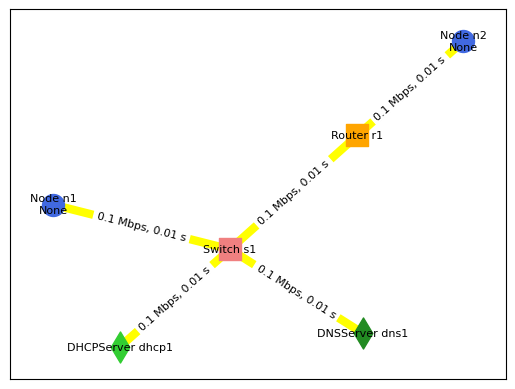

Node n1 has been assigned the IP address 192.168.1.1/24.
Node n1 has been assigned the DNS server IP address 192.168.1.200/24.
n1 DNS record added: www.example.com -> 192.168.2.1/24
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:10910 from port 22246
Sending TCP packet from n1 to 192.168.2.1/24:10910 with Flags: SYN, Data Length: 0, Sequence Number: 6469, Acknowledgment Number: 0, 
Connection state updated to SYN_SENT for 192.168.2.1/24:10910
Sending TCP packet from n2 to 192.168.1.1/24:22246 with Flags: SYN,ACK, Data Length: 0, Sequence Number: 792, Acknowledgment Number: 6470, 
TCP connection state updated to ESTABLISHED for ('192.168.1.1/24', 22246)
TCP connection state updated to ESTABLISHED for ('192.168.2.1/24', 10910)
Sending TCP packet from n1 to 192.168.2.1/24:10910 with Flags: ACK, Data Length: 0, Sequence Number: 6470, Acknowledgment Number: 793, 
Sending TCP packet from n1 to 192.168.2.1/24:10910 with Flags: PSH, Data Length: 100, Sequence Number: 6470, Acknowledgm

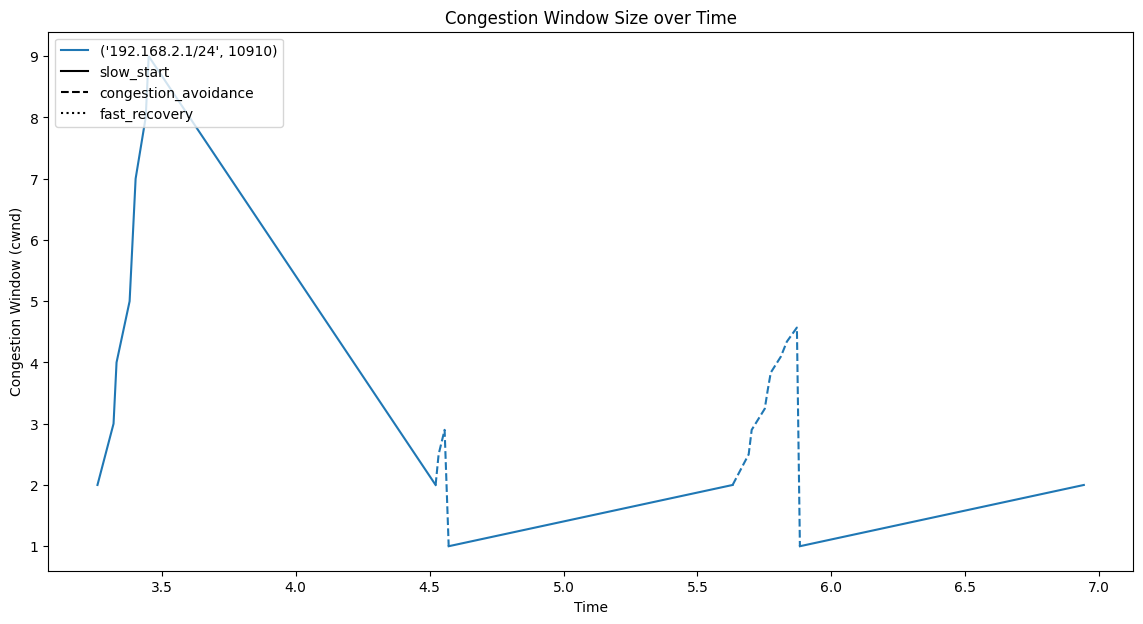

In [2]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec12a.NetworkEventScheduler import NetworkEventScheduler
from sec12a.Node import Node
from sec12a.Switch import Switch
from sec12a.Router import Router
from sec12a.Server import DNSServer, DHCPServer
from sec12a.Link import Link

nes = NetworkEventScheduler(seed=7, log_enabled=True, verbose=False, tcp_verbose=True)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)  # DHCP利用
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)  # IPアドレスを静的に設定
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.1, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)

# 通信アプリケーションの設定
node1.start_tcp_traffic(destination_url="www.example.com", bitrate=1000000000, start_time=1.0, duration=5.0, header_size=50, payload_size=100)

# イベントスケジューラを実行
nes.run_until(10.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_arp_table()
node1.print_url_to_ip_mapping()
node1.print_tcp_connections()
router1.print_arp_table()
router1.print_routing_table()
node2.print_arp_table()
node2.print_tcp_connections()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)
nes.plot_cwnd_log()


## 高速回復（Fast Recovery）

### TCP Tahoeの課題

先ほど実装したTCP Tahoeというアルゴリズムでは、タイムアウトや重複ACKを検出した際、つまりパケットロスが発生した際に輻輳ウィンドウ (cwnd) を1 MSSまで急激に減少させ、スロースタートから再開します。
これはネットワークが激しく混雑した際などには適切なアプローチですが、一方で軽微なネットワーク混雑時にも過剰な反応をしてしまう可能性があります。
つまり、ちょっとした混雑なのに送信データ量を一気に落としてしまい、cwndが回復するまでネットワークの利用効率が低下してしまいます。

### TCP Reno

上記の課題に対して開発されたのが、TCP Renoというアルゴリズムです。
これも古典的なアルゴリズムなので、今では使われることはまずありませんが、考え方の学習にはとても適しています。
TCP Renoは重複ACKによるパケットロス検出時に、高速回復アルゴリズムを使用します。
cwndを半分に減少させるだけで、スロースタートには戻りません。
そのため軽微なパケットロス時でもスループットを維持できます。
また、TCP Renoはタイムアウトと重複ACKを区別し、それぞれに適切に対応します。
タイムアウト時はTahoeと同様にスロースタートに戻りますが、重複ACK時は高速回復を使用します。

TCP Reno では `fast_recovery` 状態が追加されます。
具体的には、重複 ACK を 3 回受け取った後、Fast Retransmit の実行に加え、`fast_recovery` 状態に移行します。
この `fast_recovery` 状態では、重複 ACK を受け取るたびに cwnd を 1 ずつ増加させ、再送信後も新しいデータを送信し続けます。

### TCP Renoの実装

#### 状態遷移

状態を変える`transition_to_state`メソッドを更新します。
`fast_recovery` 状態に遷移する際には、現在のcwndを半分にし、その後に3を加えます。
これは、ネットワークの輻輳が検出された後にデータ送信量を減らしつつも、スロースタートに戻るのではなく、ある程度のデータ送信を維持するためです。
重複したACKを3回受け取ることで、パケットのロスが検出されたと見なし、この操作を行います。
この際、ssthresh も現在のcwndの半分に設定され、ネットワークの状態が改善されるまでデータ送信量を適度に抑えます。


```
    def transition_to_state(self, connection_key, new_state):
        """指定された状態へ遷移し、関連する操作を行います。"""
        if connection_key not in self.tcp_connections:
            return

        current_state = self.tcp_connections[connection_key]['congestion_state']
        if current_state == new_state:
            return  # 同じ状態に遷移しようとした場合は何もしない

        # 現在のcwndとssthreshを取得
        cwnd = self.tcp_connections[connection_key]['cwnd']
        ssthresh = self.tcp_connections[connection_key]['ssthresh']

        if new_state == 'slow_start':
            # スロースタート状態への遷移
            self.tcp_connections[connection_key]['cwnd'] = 1
            self.tcp_connections[connection_key]['ssthresh'] = max(cwnd // 2, 2)
            self.tcp_connections[connection_key]['congestion_state'] = new_state
            if self.network_event_scheduler.tcp_verbose:
                print(f"Transitioning to {new_state} for connection {connection_key}. ssthresh set to {ssthresh}, cwnd reset to 1.")

        elif new_state == 'congestion_avoidance':
            # 輻輳回避状態への遷移
            self.tcp_connections[connection_key]['congestion_state'] = new_state
            if self.network_event_scheduler.tcp_verbose:
                print(f"Transitioning to {new_state} for connection {connection_key}. Continuing to increase cwnd linearly.")

        elif new_state == 'fast_recovery':
            # Fast Recovery状態への遷移
            self.tcp_connections[connection_key]['ssthresh'] = max(cwnd // 2, 2)
            self.tcp_connections[connection_key]['cwnd'] = ssthresh + 3  # ssthresh + 3つの重複ACKを考慮
            self.tcp_connections[connection_key]['congestion_state'] = new_state
            if self.network_event_scheduler.tcp_verbose:
                print(f"Transitioning to {new_state} for connection {connection_key}. cwnd set to {self.tcp_connections[connection_key]['cwnd']}.")

        self.log_congestion_window(connection_key, self.tcp_connections[connection_key]['cwnd'], new_state)
```

#### タイムアウト時の処理

`handle_timeout`関数は、TCP接続においてタイムアウトが発生した際に呼び出され、対応する処理を実行します。
タイムアウトが発生すると、特定のパケットの再送を試み、再送試行回数が一定の限度に達するとパケットを破棄します。
さらに、TCP Renoではタイムアウトが発生した場合にスロースタート状態に戻ります。

まず、関数はタイムアウトしたパケットがウィンドウに存在するかどうかを確認します。
存在する場合、そのパケットの再送試行回数をチェックします。
再送試行回数が最大試行回数に達していなければ、そのパケットを再送します。
再送試行回数が最大試行回数に達していれば、そのパケットをウィンドウから削除します。
次に、TCP Renoの規則に従って、タイムアウトが発生した場合にスロースタート状態に遷移します。

```
    def handle_timeout(self, connection_key, sequence_number):
        """
        タイムアウトしたパケットに対する処理を行います。
        """
        if connection_key in self.windows and sequence_number in self.windows[connection_key]:
            attempt = self.windows[connection_key][sequence_number]["attempt"]
            packet_info = self.windows[connection_key][sequence_number]["packet_info"]
            
            # 再送試行回数をチェック
            if attempt < self.max_attempts - 1:
                if self.network_event_scheduler.tcp_verbose:
                    print(f"Timeout for sequence number {sequence_number}. Retransmitting packet.")
                # パケット情報から再送するパケットを再構築
                self.retransmit_packet(connection_key, sequence_number)
            else:
                # 最大試行回数に達した場合、パケットをドロップ
                if self.network_event_scheduler.tcp_verbose:
                    print(f"Maximum attempts reached for sequence number: {sequence_number}. Dropping packet.")
                del self.windows[connection_key][sequence_number]  # タイムアウトしたパケットをウィンドウから削除

            # Renoでは、タイムアウトが発生した場合、スロースタートに戻る
            self.transition_to_state(connection_key, 'slow_start')
            
            # タイムアウト処理の完了をログに記録
            if self.network_event_scheduler.tcp_verbose:
                print(f"Timeout handled for connection {connection_key}. State transitioned to slow_start.")
```






### 高速回復の確認

アップデートした`Node`クラスを用いて、TCP Renoの高速回復の挙動を確認してみます。
輻輳ウインドウの確認の方法は、先ほどと同じです。

今回もパケットロスが発生しない場合には、輻輳ウインドウは徐々に大きくなり、そのまま最大値（今回は64）をとり続けます。
スロースタートによる指数関数的な増加から、ssthreshを超えてからの線形な増加へと切り替わることが確認できます。

リンクでパケットロスが発生するように設定すると、パケットロス時の輻輳ウインドウの縮小と回復を模擬できます。
先ほどとは異なり、パケットロス時に輻輳ウインドウが1まで低下せず、cwndが比較的高い状態を維持できることを確認しましょう。


Cloning into 'network-simulator'...
remote: Enumerating objects: 1761, done.
remote: Counting objects: 100% (429/429), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 1761 (delta 315), reused 419 (delta 305), pack-reused 1332
Receiving objects: 100% (1761/1761), 314.14 KiB | 2.83 MiB/s, done.
Resolving deltas: 100% (1316/1316), done.


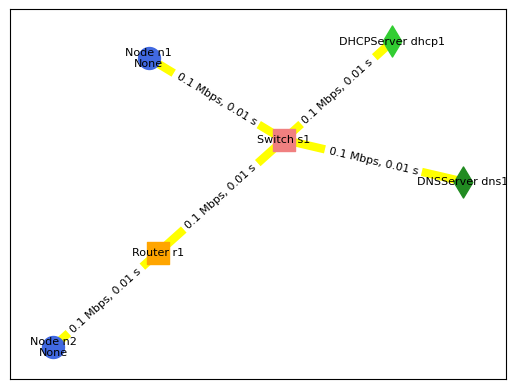

Node n1 has been assigned the IP address 192.168.1.1/24.
Node n1 has been assigned the DNS server IP address 192.168.1.200/24.
n1 DNS record added: www.example.com -> 192.168.2.1/24
Initiating TCP handshake: Sending SYN to 192.168.2.1/24:10910 from port 22246
Sending TCP packet from n1 to 192.168.2.1/24:10910 with Flags: SYN, Data Length: 0, Sequence Number: 6469, Acknowledgment Number: 0, 
Connection state updated to SYN_SENT for 192.168.2.1/24:10910
Sending TCP packet from n2 to 192.168.1.1/24:22246 with Flags: SYN,ACK, Data Length: 0, Sequence Number: 792, Acknowledgment Number: 6470, 
TCP connection state updated to ESTABLISHED for ('192.168.1.1/24', 22246)
TCP connection state updated to ESTABLISHED for ('192.168.2.1/24', 10910)
Sending TCP packet from n1 to 192.168.2.1/24:10910 with Flags: ACK, Data Length: 0, Sequence Number: 6470, Acknowledgment Number: 793, 
Sending TCP packet from n1 to 192.168.2.1/24:10910 with Flags: PSH, Data Length: 100, Sequence Number: 6470, Acknowledgm

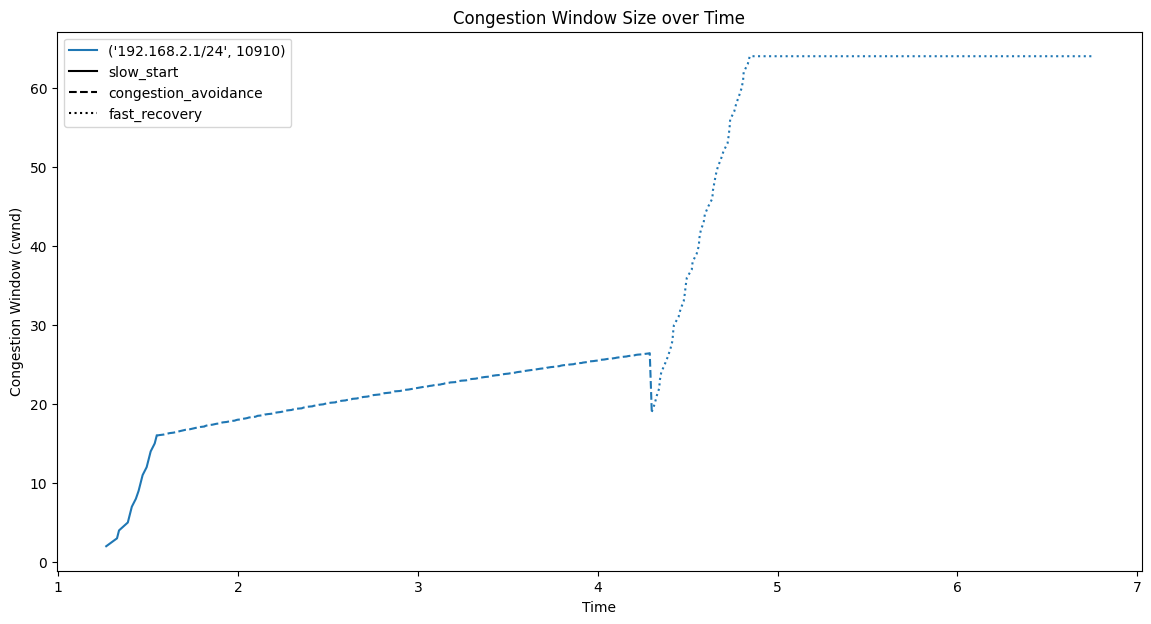

In [ ]:
import sys

!git clone https://github.com/flyby-yunakayama/network-simulator.git
sys.path.insert(0,'/content/network-simulator')

from sec12b.NetworkEventScheduler import NetworkEventScheduler
from sec12b.Node import Node
from sec12b.Switch import Switch
from sec12b.Router import Router
from sec12b.Server import DNSServer, DHCPServer
from sec12b.Link import Link

nes = NetworkEventScheduler(seed=7, log_enabled=True, verbose=False, tcp_verbose=True)

# ノードとルータの設定
node1 = Node(node_id="n1", ip_address="192.168.1.0/24", network_event_scheduler=nes)  # DHCP利用
node2 = Node(node_id="n2", ip_address="192.168.2.1/24", network_event_scheduler=nes)  # IPアドレスを静的に設定
switch1 = Switch(node_id="s1", ip_address="192.168.1.240/24", network_event_scheduler=nes)
router1 = Router(node_id="r1", ip_addresses=["192.168.1.254/24", "192.168.2.254/24"], network_event_scheduler=nes)
dns1 = DNSServer(node_id="dns1", ip_address="192.168.1.200/24", network_event_scheduler=nes)
dhcp1 = DHCPServer(node_id="dhcp1", ip_address="192.168.1.250/24", dns_server_ip="192.168.1.200/24", start_cidr="192.168.1.0/24", network_event_scheduler=nes)

# リンクの設定
link1 = Link(node1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.001, network_event_scheduler=nes)
link2 = Link(switch1, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link3 = Link(dns1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link4 = Link(dhcp1, switch1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)
link5 = Link(node2, router1, bandwidth=100000, delay=0.01, loss_rate=0.0, network_event_scheduler=nes)

# ネットワークのトポロジを描画
nes.draw()

# DNSサーバに対してDNSレコード設定
dns1.add_dns_record("www.example.com", "192.168.2.1/24")

# DHCPサーバに対して使用済みIPアドレス登録
used_ips = ["192.168.1.240/24", "192.168.1.254/24", "192.168.1.200/24", "192.168.1.250/24"]
dhcp1.mark_ips_as_used(used_ips)

# 通信アプリケーションの設定
node1.start_tcp_traffic(destination_url="www.example.com", bitrate=1000000000, start_time=1.0, duration=5.0, header_size=50, payload_size=100)

# イベントスケジューラを実行
nes.run_until(10.0)

# フォワーディングテーブルやルーティングテーブルを確認
node1.print_arp_table()
node1.print_url_to_ip_mapping()
node1.print_tcp_connections()
router1.print_arp_table()
router1.print_routing_table()
node2.print_arp_table()
node2.print_tcp_connections()

# 結果を確認
nes.generate_summary(nes.packet_logs)
#nes.generate_throughput_graph(nes.packet_logs)
#nes.generate_delay_histogram(nes.packet_logs)
nes.plot_cwnd_log()


### 演習課題1: TCP Tahoeにおける輻輳ウインドウの確認

#### 目的
TCPのデータレートを制御する輻輳ウインドウの挙動をトレースし、その仕組みを理解する。

#### 課題の概要
TCP Tahoeを用いて、パケットロス率を増減させながらTCPパケットを送受信してみましょう。
パケットロス率が高いとき、輻輳ウインドウサイズが小さい状態をとる時間が長くなり、データレートが上がらないことを確認しましょう。

### 演習課題2: TCP Renoにおける高速回復の確認

#### 目的
TCP輻輳制御における状態遷移の工夫について理解する。

#### 課題
TCP Renoを用いて、パケットロス率を増減させながらTCPパケットを送受信してみましょう。
パケットロス率が高いときにも、Tahoeと比べて輻輳ウインドウが低くなりにくいことを確認しましょう。


## 本章のまとめ

本章では、TCPの通信レートを調整するウインドウ制御について学習しました。
ネットワークの混雑を防ぎつつ、効率的にパケットを送受信するため、輻輳ウインドウを増減させます。
本章では古典的なアルゴリズムであるTahoeとRenoを題材にして、輻輳ウインドウ制御の基本的な挙動について学びました。
これらのアルゴリズムでは、パケットロスを混雑の指標として用います。
徐々に輻輳ウインドウを大きくしていき、ロスがあった際には大幅に低下させることでネットワークの状態に応じてパケット送出量を調整します。
TCPには、このように信頼性や効率性を高めるための仕組みが実装されているのです。
